# 04 — Baseline HMER Model

This notebook implements the first handwritten mathematical expression recognition baseline.

Pipeline:

**Processed CROHME image → CNN Encoder → LSTM Decoder → LaTeX token sequence**

The baseline intentionally does not use attention. It uses the outputs produced by the preprocessing and validation notebooks:
- processed PNG images
- JSONL manifests
- canonical vocabulary
- precomputed token IDs

It does **not** re-parse InkML files or rebuild the vocabulary..


In [1]:
#helper function to display the path in a more readable format
def display_path(path):
    return "/HMER" + str(path).split("/HMER", 1)[1]

In [2]:
from pathlib import Path
import json
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence


In [3]:
# Project paths and configuration

PROJECT_ROOT = Path.cwd().resolve()

# If the notebook is executed from notebooks/, move one level up.
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_ROOT = PROJECT_ROOT / "data"
CROHME_ROOT = DATA_ROOT / "crohme2019"
PROCESSED_ROOT = DATA_ROOT / "processed" / "crohme2019"

MANIFEST_ROOT = PROCESSED_ROOT / "manifests"
METADATA_ROOT = PROCESSED_ROOT / "metadata"
IMAGE_ROOT = PROCESSED_ROOT / "images"

OUTPUT_ROOT = PROJECT_ROOT / "outputs"
MODEL_ROOT = OUTPUT_ROOT / "models"

MODEL_ROOT.mkdir(parents=True, exist_ok=True)

# Processed images were created at height 128 during preprocessing.
IMAGE_HEIGHT = 128

# Width is deliberately NOT fixed. The collate function pads each batch
# to its widest image so that the original aspect ratio is preserved.
MAX_IMAGE_WIDTH = 1024

BATCH_SIZE = 8
NUM_EPOCHS = 20
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5

EMBEDDING_DIM = 256
HIDDEN_DIM = 512
NUM_LAYERS = 1
DROPOUT = 0.0

# None means that the complete validated target sequence is used.
MAX_TARGET_LENGTH = None

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)

print(f"Project root   : {display_path(PROJECT_ROOT)}")
print(f"Processed root : {display_path(PROCESSED_ROOT)}")
print(f"Manifest root  : {display_path(MANIFEST_ROOT)}")
print(f"Image root     : {display_path(IMAGE_ROOT)}")
print(f"Device         : {DEVICE}")


Project root   : /HMER
Processed root : /HMER/data/processed/crohme2019
Manifest root  : /HMER/data/processed/crohme2019/manifests
Image root     : /HMER/data/processed/crohme2019/images
Device         : cuda


In [4]:
# Verify the processed dataset produced by notebooks 02 and 03
required_paths = [
    PROCESSED_ROOT,
    MANIFEST_ROOT,
    METADATA_ROOT,
    IMAGE_ROOT,
]

for path in required_paths:
    assert path.exists(), f"Required path does not exist: {path}"

for split in ["train", "valid", "test"]:
    manifest_path = MANIFEST_ROOT / f"{split}.jsonl"
    image_dir = IMAGE_ROOT / split

    assert manifest_path.exists(), f"Missing manifest: {manifest_path}"
    assert image_dir.exists(), f"Missing image directory: {image_dir}"

VOCAB_PATH = METADATA_ROOT / "vocab.json"
assert VOCAB_PATH.exists(), f"Missing vocabulary: {VOCAB_PATH}"

print("Processed dataset structure verified.")


Processed dataset structure verified.


In [5]:
# Load the canonical vocabulary

with open(VOCAB_PATH, "r", encoding="utf-8") as file:
    vocab_data = json.load(file)

# Support the project's canonical vocab.json structure.
if "token_to_id" in vocab_data:
    token_to_id = {str(k): int(v) for k, v in vocab_data["token_to_id"].items()}
elif "vocabulary" in vocab_data and isinstance(vocab_data["vocabulary"], dict):
    token_to_id = {str(k): int(v) for k, v in vocab_data["vocabulary"].items()}
else:
    # Fallback for a direct token -> ID mapping.
    token_to_id = {str(k): int(v) for k, v in vocab_data.items()}

if "id_to_token" in vocab_data:
    id_to_token = {int(k): str(v) for k, v in vocab_data["id_to_token"].items()}
else:
    id_to_token = {idx: token for token, idx in token_to_id.items()}

PAD_TOKEN = "<PAD>"
SOS_TOKEN = "<SOS>"
EOS_TOKEN = "<EOS>"
UNK_TOKEN = "<UNK>"

for special_token in [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN, UNK_TOKEN]:
    assert special_token in token_to_id, (
        f"{special_token} is missing from the canonical vocabulary."
    )

PAD_ID = token_to_id[PAD_TOKEN]
SOS_ID = token_to_id[SOS_TOKEN]
EOS_ID = token_to_id[EOS_TOKEN]
UNK_ID = token_to_id[UNK_TOKEN]

VOCAB_SIZE = len(token_to_id)

print("Vocabulary size:", VOCAB_SIZE)
print("Special tokens:")
print(f"  {PAD_TOKEN}: {PAD_ID}")
print(f"  {SOS_TOKEN}: {SOS_ID}")
print(f"  {EOS_TOKEN}: {EOS_ID}")
print(f"  {UNK_TOKEN}: {UNK_ID}")


Vocabulary size: 121
Special tokens:
  <PAD>: 0
  <SOS>: 1
  <EOS>: 2
  <UNK>: 3


In [6]:
# Load processed JSONL manifests

def load_manifest(split):
    manifest_path = MANIFEST_ROOT / f"{split}.jsonl"

    records = []
    with open(manifest_path, "r", encoding="utf-8") as file:
        for line_number, line in enumerate(file, start=1):
            line = line.strip()
            if not line:
                continue

            record = json.loads(line)
            record["_manifest_line"] = line_number
            records.append(record)

    return records


train_records = load_manifest("train")
valid_records = load_manifest("valid")
test_records = load_manifest("test")

print("Manifest records")
print("  Train:", len(train_records))
print("  Valid:", len(valid_records))
print("  Test :", len(test_records))


Manifest records
  Train: 8886
  Valid: 972
  Test : 1199


In [7]:
# ============================================================
# Resolve image paths from manifest records
# ============================================================

def resolve_image_path(record):
    # The preprocessing notebook stores the processed image path
    # relative to PROCESSED_ROOT.
    image_value = record.get("image")

    if image_value:
        image_path = Path(image_value)
        if not image_path.is_absolute():
            image_path = PROCESSED_ROOT / image_path

        if image_path.exists():
            return image_path

    # Fallback based on the manifest split and ID/file fields.
    record_id = record.get("id")
    split = record.get("split")

    if record_id and split:
        candidate = IMAGE_ROOT / split / f"{record_id}.png"
        if candidate.exists():
            return candidate

    file_value = record.get("file")
    if file_value and split:
        candidate = IMAGE_ROOT / split / Path(file_value).with_suffix(".png").name
        if candidate.exists():
            return candidate

    return None


def validate_records(records, split):
    valid = []
    missing = []
    unreadable = []

    for record in records:
        image_path = resolve_image_path(record)

        if image_path is None:
            missing.append(record)
            continue

        try:
            with Image.open(image_path) as image:
                image.verify()
        except (UnidentifiedImageError, OSError, ValueError):
            unreadable.append((record, image_path))
            continue

        record = dict(record)
        record["_image_path"] = str(image_path)
        valid.append(record)

    if missing:
        print(f"[{split}] Missing images excluded: {len(missing)}")

    if unreadable:
        print(f"[{split}] Unreadable images excluded: {len(unreadable)}")
        for record, image_path in unreadable[:10]:
            print("  -", image_path)

    return valid


train_records = validate_records(train_records, "train")
valid_records = validate_records(valid_records, "valid")
test_records = validate_records(test_records, "test")

print()
print("Usable records")
print("  Train:", len(train_records))
print("  Valid:", len(valid_records))
print("  Test :", len(test_records))



Usable records
  Train: 8886
  Valid: 972
  Test : 1199


In [8]:
# ============================================================
# Validate the token IDs supplied by the preprocessing pipeline
# ============================================================

def validate_token_ids(records, split):
    errors = []

    for record in records:
        token_ids = [int(x) for x in record["token_ids"]]

        if not token_ids:
            errors.append((record["id"], "empty token_ids"))
            continue

        if token_ids[0] != SOS_ID:
            errors.append((record["id"], "missing SOS"))

        if token_ids[-1] != EOS_ID:
            errors.append((record["id"], "missing EOS"))

        expected_length = int(record["sequence_length"])
        if len(token_ids) != expected_length:
            errors.append(
                (record["id"], f"sequence_length={expected_length}, actual={len(token_ids)}")
            )

    if errors:
        raise ValueError(
            f"{split} contains {len(errors)} invalid token sequences. "
            f"First errors: {errors[:5]}"
        )

    print(f"{split}: token IDs validated ({len(records)} records).")


validate_token_ids(train_records, "train")
validate_token_ids(valid_records, "valid")
validate_token_ids(test_records, "test")


train: token IDs validated (8886 records).
valid: token IDs validated (972 records).
test: token IDs validated (1199 records).


In [9]:
# ============================================================
# Decode token IDs for display only
# ============================================================

def decode_ids(ids):
    tokens = []

    for raw_id in ids:
        idx = int(raw_id)

        if idx == PAD_ID:
            continue

        if idx == SOS_ID:
            continue

        if idx == EOS_ID:
            break

        token = id_to_token.get(idx, UNK_TOKEN)
        tokens.append(token)

    return " ".join(tokens)


def normalized_expression_ids(ids):
    """Return the expression token sequence used for exact-match evaluation."""
    normalized = []

    for raw_id in ids:
        idx = int(raw_id)

        if idx in {PAD_ID, SOS_ID}:
            continue

        normalized.append(idx)

        if idx == EOS_ID:
            break

    return tuple(normalized)


In [10]:
# Inspect one manifest record

sample_record = train_records[0]

print("ID:", sample_record["id"])
print("LaTeX:", sample_record["latex"])
print("Token IDs:", sample_record["token_ids"])
print("Decoded:", decode_ids(sample_record["token_ids"]))
print(f"Image: {display_path(sample_record['_image_path'])}")


ID: 101_Fabricio
LaTeX: S = \Bigg( \sum_{i=1}^{n} \theta_i - (n-2)\pi \Bigg)r^2
Token IDs: [1, 94, 16, 79, 13, 41, 11, 4, 29, 16, 6, 5, 8, 4, 19, 5, 47, 11, 29, 12, 13, 19, 12, 7, 14, 48, 79, 14, 49, 8, 7, 2]
Decoded: S = \Bigg ( \sum _ { i = 1 } ^ { n } \theta _ i - ( n - 2 ) \pi \Bigg ) r ^ 2
Image: /HMER/data/processed/crohme2019/images/train/101_Fabricio.png


In [11]:
# Dataset class for HMER

class HMERDataset(Dataset):
    def __init__(
        self,
        records,
        image_height=IMAGE_HEIGHT,
        max_image_width=MAX_IMAGE_WIDTH,
        max_target_length=MAX_TARGET_LENGTH,
    ):
        self.records = list(records)
        self.image_height = image_height
        self.max_image_width = max_image_width
        self.max_target_length = max_target_length

    def __len__(self):
        return len(self.records)

    def _load_image(self, image_path):
        with Image.open(image_path) as image:
            image = image.convert("L")

            original_width, original_height = image.size

            # Processed images should already have height 128.
            # Do not force them to a fixed width.
            if original_height != self.image_height:
                scale = self.image_height / original_height
                new_width = max(1, round(original_width * scale))
                image = image.resize(
                    (new_width, self.image_height),
                    Image.Resampling.BILINEAR,
                )

            if image.width > self.max_image_width:
                raise ValueError(
                    f"Image width {image.width} exceeds MAX_IMAGE_WIDTH="
                    f"{self.max_image_width}: {image_path}"
                )

            array = np.asarray(image, dtype=np.float32) / 255.0

        return torch.from_numpy(array).unsqueeze(0)

    def _load_target(self, record):
        token_ids = [int(x) for x in record["token_ids"]]

        if self.max_target_length is not None and len(token_ids) > self.max_target_length:
            # Preserve EOS when truncating.
            token_ids = (
                token_ids[: self.max_target_length - 1]
                + [EOS_ID]
            )

        return torch.tensor(token_ids, dtype=torch.long)

    def __getitem__(self, index):
        record = self.records[index]

        image = self._load_image(record["_image_path"])
        target = self._load_target(record)

        return image, target


In [12]:
train_dataset = HMERDataset(train_records)
valid_dataset = HMERDataset(valid_records)
test_dataset = HMERDataset(test_records)

print("Train dataset:", len(train_dataset))
print("Valid dataset:", len(valid_dataset))
print("Test dataset :", len(test_dataset))


Train dataset: 8886
Valid dataset: 972
Test dataset : 1199


In [13]:
# Dataset sample sanity check

image, target = train_dataset[0]

print("Image shape :", tuple(image.shape))
print("Target shape:", tuple(target.shape))
print("Target IDs  :", target.tolist())
print("Target LaTeX:", decode_ids(target.tolist()))


Image shape : (1, 128, 622)
Target shape: (32,)
Target IDs  : [1, 94, 16, 79, 13, 41, 11, 4, 29, 16, 6, 5, 8, 4, 19, 5, 47, 11, 29, 12, 13, 19, 12, 7, 14, 48, 79, 14, 49, 8, 7, 2]
Target LaTeX: S = \Bigg ( \sum _ { i = 1 } ^ { n } \theta _ i - ( n - 2 ) \pi \Bigg ) r ^ 2


In [14]:
# ============================================================
# Batch collation
# ============================================================
# Images keep their original aspect ratios. Width is padded only
# within a batch. Padding uses 1.0 because the rendered images
# have a white background and pixel values are normalized to [0, 1].

def collate_fn(batch):
    images, targets = zip(*batch)

    max_height = max(image.shape[1] for image in images)
    max_width = max(image.shape[2] for image in images)

    padded_images = []

    for image in images:
        height, width = image.shape[1], image.shape[2]

        padded = torch.ones(
            (1, max_height, max_width),
            dtype=image.dtype,
        )

        padded[:, :height, :width] = image
        padded_images.append(padded)

    images = torch.stack(padded_images)

    targets = pad_sequence(
        targets,
        batch_first=True,
        padding_value=PAD_ID,
    )

    return images, targets


In [15]:
# ============================================================
# DataLoaders
# ============================================================

NUM_WORKERS = 0

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    collate_fn=collate_fn,
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    collate_fn=collate_fn,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    collate_fn=collate_fn,
)


In [16]:
# Batch sanity check

images, targets = next(iter(train_loader))

print("Images :", tuple(images.shape))
print("Targets:", tuple(targets.shape))

print("\nFirst target lengths:")
for target in targets[:5]:
    print(int((target != PAD_ID).sum()))


Images : (8, 1, 128, 1024)
Targets: (8, 37)

First target lengths:
15
16
20
37
24


In [17]:
# ============================================================
# CNN Encoder
# ============================================================
# This is intentionally a simple baseline CNN. Spatial information
# is compressed to a single representation before the LSTM decoder.
# No attention mechanism is used in this baseline.

class CNNEncoder(nn.Module):
    def __init__(self, hidden_dim=HIDDEN_DIM):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.projection = nn.Linear(512, hidden_dim)

    def forward(self, images):
        features = self.features(images)
        features = features.flatten(1)
        return self.projection(features)


In [18]:
# ============================================================
# LSTM Decoder
# ============================================================

class LSTMDecoder(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim=EMBEDDING_DIM,
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT,
    ):
        super().__init__()

        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=PAD_ID,
        )

        self.image_to_hidden = nn.Linear(
            hidden_dim,
            hidden_dim * num_layers,
        )

        self.image_to_cell = nn.Linear(
            hidden_dim,
            hidden_dim * num_layers,
        )

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.output_projection = nn.Linear(
            hidden_dim,
            vocab_size,
        )

    def initialize_state(self, image_features):
        batch_size = image_features.size(0)

        hidden = self.image_to_hidden(image_features)
        cell = self.image_to_cell(image_features)

        hidden = hidden.view(
            self.num_layers,
            batch_size,
            self.hidden_dim,
        )

        cell = cell.view(
            self.num_layers,
            batch_size,
            self.hidden_dim,
        )

        return hidden, cell

    def forward(self, image_features, target_sequences):
        embedded = self.embedding(target_sequences)

        hidden, cell = self.initialize_state(image_features)

        outputs, _ = self.lstm(
            embedded,
            (hidden, cell),
        )

        return self.output_projection(outputs)


In [19]:
# ============================================================
# Complete baseline model
# ============================================================

class BaselineHMER(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim=EMBEDDING_DIM,
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT,
    ):
        super().__init__()

        self.encoder = CNNEncoder(
            hidden_dim=hidden_dim,
        )

        self.decoder = LSTMDecoder(
            vocab_size=vocab_size,
            embedding_dim=embedding_dim,
            hidden_dim=hidden_dim,
            num_layers=num_layers,
            dropout=dropout,
        )

    def forward(self, images, target_sequences):
        image_features = self.encoder(images)
        return self.decoder(
            image_features,
            target_sequences,
        )


In [20]:
model = BaselineHMER(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
).to(DEVICE)

NUM_PARAMETERS = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(f"Trainable parameters: {NUM_PARAMETERS:,}")


Trainable parameters: 4,027,961


In [21]:
# ============================================================
# Forward-pass sanity check
# ============================================================

images, targets = next(iter(train_loader))

images = images.to(DEVICE)
targets = targets.to(DEVICE)

decoder_input = targets[:, :-1]

with torch.no_grad():
    logits = model(images, decoder_input)

print("Input images :", tuple(images.shape))
print("Decoder input:", tuple(decoder_input.shape))
print("Logits       :", tuple(logits.shape))

assert logits.shape[0] == images.shape[0]
assert logits.shape[1] == decoder_input.shape[1]
assert logits.shape[2] == VOCAB_SIZE


Input images : (8, 1, 128, 460)
Decoder input: (8, 21)
Logits       : (8, 21, 121)


In [22]:
# ============================================================
# Loss and optimizer
# ============================================================

criterion = nn.CrossEntropyLoss(
    ignore_index=PAD_ID,
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)


In [23]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0

    for images, targets in loader:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        # Teacher forcing:
        # input  = <SOS> token_1 token_2 ...
        # target = token_1 token_2 ... <EOS>
        decoder_input = targets[:, :-1]
        expected_output = targets[:, 1:]

        optimizer.zero_grad(set_to_none=True)

        logits = model(
            images,
            decoder_input,
        )

        loss = criterion(
            logits.reshape(-1, VOCAB_SIZE),
            expected_output.reshape(-1),
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0,
        )

        optimizer.step()

        running_loss += loss.item() * images.size(0)

    return running_loss / len(loader.dataset)


In [24]:
@torch.no_grad()
def evaluate_loss(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0

    for images, targets in loader:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        decoder_input = targets[:, :-1]
        expected_output = targets[:, 1:]

        logits = model(
            images,
            decoder_input,
        )

        loss = criterion(
            logits.reshape(-1, VOCAB_SIZE),
            expected_output.reshape(-1),
        )

        running_loss += loss.item() * images.size(0)

    return running_loss / len(loader.dataset)


In [25]:
# ============================================================
# Training
# ============================================================

history = {
    "train_loss": [],
    "valid_loss": [],
}

best_valid_loss = float("inf")
best_model_path = MODEL_ROOT / "baseline_hmer_best.pt"

for epoch in range(1, NUM_EPOCHS + 1):
    start_time = time.time()

    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        DEVICE,
    )

    valid_loss = evaluate_loss(
        model,
        valid_loader,
        criterion,
        DEVICE,
    )

    history["train_loss"].append(train_loss)
    history["valid_loss"].append(valid_loss)

    elapsed = time.time() - start_time

    print(
        f"Epoch [{epoch:02d}/{NUM_EPOCHS}] "
        f"| train loss: {train_loss:.4f} "
        f"| valid loss: {valid_loss:.4f} "
        f"| time: {elapsed:.1f}s"
    )

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss

        checkpoint = {
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "epoch": epoch,
            "valid_loss": valid_loss,
            "vocab_size": VOCAB_SIZE,
            "token_to_id": token_to_id,
            "id_to_token": id_to_token,
            "config": {
                "image_height": IMAGE_HEIGHT,
                "max_image_width": MAX_IMAGE_WIDTH,
                "embedding_dim": EMBEDDING_DIM,
                "hidden_dim": HIDDEN_DIM,
                "num_layers": NUM_LAYERS,
                "dropout": DROPOUT,
            },
        }

        torch.save(
            checkpoint,
            best_model_path,
        )

        print(f"  Saved best model -> {display_path(best_model_path)}")

print("\nTraining complete.")


Epoch [01/20] | train loss: 1.8077 | valid loss: 2.5971 | time: 71.0s
  Saved best model -> /HMER/outputs/models/baseline_hmer_best.pt
Epoch [02/20] | train loss: 1.1875 | valid loss: 2.6342 | time: 67.9s
Epoch [03/20] | train loss: 1.0437 | valid loss: 2.6416 | time: 66.9s
Epoch [04/20] | train loss: 0.9689 | valid loss: 2.6983 | time: 68.2s
Epoch [05/20] | train loss: 0.9084 | valid loss: 2.7670 | time: 66.1s
Epoch [06/20] | train loss: 0.8579 | valid loss: 2.8107 | time: 70.7s
Epoch [07/20] | train loss: 0.8138 | valid loss: 2.8519 | time: 64.2s
Epoch [08/20] | train loss: 0.7709 | valid loss: 2.8760 | time: 72.7s
Epoch [09/20] | train loss: 0.7376 | valid loss: 3.0356 | time: 62.5s
Epoch [10/20] | train loss: 0.7038 | valid loss: 3.0160 | time: 72.0s
Epoch [11/20] | train loss: 0.6723 | valid loss: 3.0597 | time: 62.0s
Epoch [12/20] | train loss: 0.6433 | valid loss: 3.1108 | time: 71.8s
Epoch [13/20] | train loss: 0.6103 | valid loss: 3.2265 | time: 63.9s
Epoch [14/20] | train los

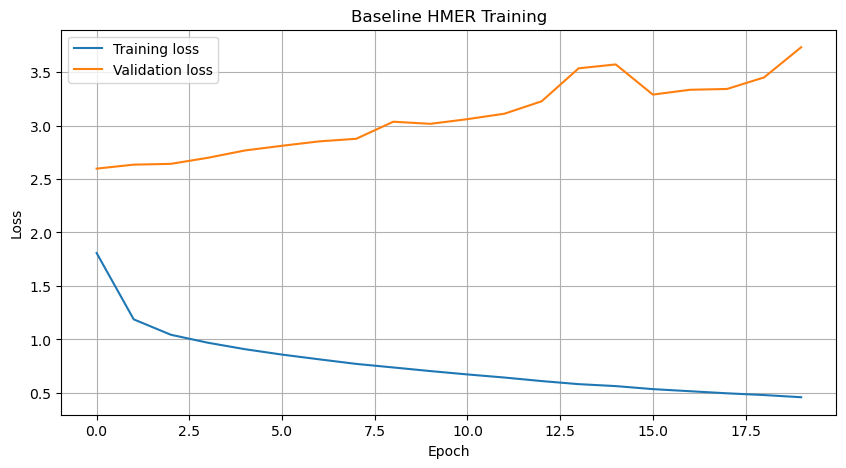

In [26]:
# ============================================================
# Training curves
# ============================================================

plt.figure(figsize=(10, 5))
plt.plot(history["train_loss"], label="Training loss")
plt.plot(history["valid_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline HMER Training")
plt.legend()
plt.grid(True)
plt.show()


In [27]:
# ============================================================
# Load the best checkpoint
# ============================================================

checkpoint = torch.load(
    best_model_path,
    map_location=DEVICE,
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

print("Loaded checkpoint from epoch:", checkpoint["epoch"])
print("Best validation loss:", checkpoint["valid_loss"])


Loaded checkpoint from epoch: 1
Best validation loss: 2.597062509246324


In [28]:
# ============================================================
# Greedy autoregressive decoding
# ============================================================

@torch.no_grad()
def predict_greedy(
    model,
    image,
    device,
    max_length=MAX_TARGET_LENGTH,
):
    model.eval()

    if image.dim() == 3:
        image = image.unsqueeze(0)

    image = image.to(device)

    image_features = model.encoder(image)
    hidden, cell = model.decoder.initialize_state(
        image_features
    )

    batch_size = image.size(0)

    current_token = torch.full(
        (batch_size, 1),
        SOS_ID,
        dtype=torch.long,
        device=device,
    )

    generated = []

    # If no explicit maximum is configured, use a safe upper bound.
    decode_length = max_length if max_length is not None else 150

    finished = torch.zeros(
        batch_size,
        dtype=torch.bool,
        device=device,
    )

    for _ in range(decode_length):
        embedded = model.decoder.embedding(current_token)

        output, (hidden, cell) = model.decoder.lstm(
            embedded,
            (hidden, cell),
        )

        logits = model.decoder.output_projection(
            output[:, -1, :]
        )

        next_token = logits.argmax(dim=-1)

        generated.append(next_token)

        finished |= next_token.eq(EOS_ID)

        current_token = next_token.unsqueeze(1)

        if torch.all(finished):
            break

    if not generated:
        return torch.empty(
            (batch_size, 0),
            dtype=torch.long,
            device=device,
        )

    return torch.stack(
        generated,
        dim=1,
    )


In [29]:
# ============================================================
# Single validation example
# ============================================================

sample_index = 0

image, target = valid_dataset[sample_index]

prediction_ids = predict_greedy(
    model,
    image,
    DEVICE,
)[0].cpu().tolist()

ground_truth = decode_ids(target.tolist())
prediction = decode_ids(prediction_ids)

print("Ground truth:")
print(ground_truth)

print("\nPrediction:")
print(prediction)


Ground truth:
x _ k x x _ k + y _ k y x _ k

Prediction:
\frac { 1 } { \frac { 1 } { 2 } \Big ( \frac { 1 } { a } + \frac { b } { a } + \frac { b } { a + b } ) ^ { \frac { a } { b } } { C }


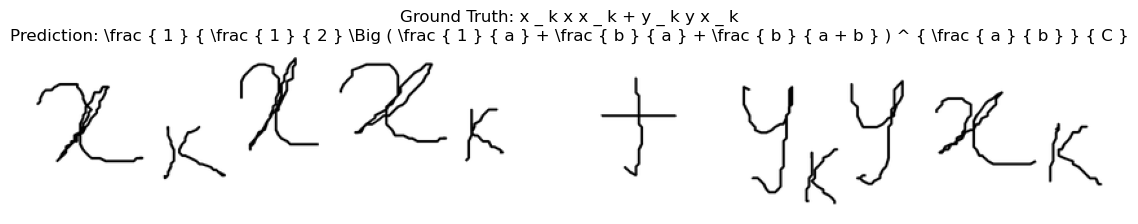

In [30]:
plt.figure(figsize=(14, 4))
plt.imshow(
    image.squeeze(0),
    cmap="gray",
)
plt.axis("off")
plt.title(
    f"Ground Truth: {ground_truth}\n"
    f"Prediction: {prediction}"
)
plt.show()


In [31]:
# Exact expression-rate evaluation

# ExpRate compares token-ID sequences rather than decoded strings.
# This avoids differences caused only by display formatting.
# PAD and SOS are ignored; comparison stops at EOS.

@torch.no_grad()
def calculate_expression_rate(
    model,
    dataset,
    device,
    max_samples=None,
):
    model.eval()

    total = (
        len(dataset)
        if max_samples is None
        else min(len(dataset), max_samples)
    )

    correct = 0
    predictions = []

    for index in range(total):
        image, target = dataset[index]

        predicted_ids = predict_greedy(
            model,
            image,
            device,
        )[0].cpu().tolist()

        ground_truth_ids = normalized_expression_ids(
            target.tolist()
        )

        prediction_ids = normalized_expression_ids(
            predicted_ids
        )

        is_correct = (
            ground_truth_ids == prediction_ids
        )

        correct += int(is_correct)

        predictions.append({
            "index": index,
            "ground_truth": decode_ids(
                target.tolist()
            ),
            "prediction": decode_ids(
                predicted_ids
            ),
            "ground_truth_ids": list(
                ground_truth_ids
            ),
            "prediction_ids": list(
                prediction_ids
            ),
            "correct": is_correct,
        })

    expression_rate = (
        correct / total
        if total
        else 0.0
    )

    return expression_rate, predictions


In [32]:
# Validation ExpRate

valid_exprate, valid_predictions = calculate_expression_rate(
    model,
    valid_dataset,
    DEVICE,
)

print(
    f"Validation ExpRate: "
    f"{valid_exprate * 100:.2f}%"
)


Validation ExpRate: 0.00%


In [33]:
prediction_df = pd.DataFrame(
    valid_predictions
)

prediction_df.head(20)


,index,ground_truth,prediction,ground_truth_ids,prediction_ids,correct
0,0,x _ k x x _ k + y _ k y x _ k,\frac { 1 } { \frac { 1 } { 2 } \Big ( \frac {...,"[10, 11, 39, 10, 10, 11, 39, 9, 23, 11, 39, 23...","[15, 4, 6, 5, 4, 15, 4, 6, 5, 4, 7, 5, 114, 13...",False
1,1,\sqrt { 4 8 },\frac { 1 } { 3 } \pi r ^ 2 h,"[22, 4, 24, 37, 5, 2]","[15, 4, 6, 5, 4, 17, 5, 48, 49, 8, 7, 68, 2]",False
2,2,2 6,\frac { 1 } { 3 } \pi r ^ 2 h,"[7, 33, 2]","[15, 4, 6, 5, 4, 17, 5, 48, 49, 8, 7, 68, 2]",False
3,3,q _ t = 2 q,\frac { 1 } { \frac { 1 } { 2 } \Big ( \frac {...,"[59, 11, 38, 16, 7, 59, 2]","[15, 4, 6, 5, 4, 15, 4, 6, 5, 4, 7, 5, 114, 13...",False
4,4,\frac { p e ^ t } { 1 - ( 1 - p ) e ^ t } <UNK>,\frac { 1 } { \frac { 1 } { 2 } \Big ( \frac {...,"[15, 4, 46, 51, 8, 38, 5, 4, 6, 12, 13, 6, 12,...","[15, 4, 6, 5, 4, 15, 4, 6, 5, 4, 7, 5, 114, 13...",False
5,5,4 ^ 2 + 4 ^ 2 + \frac { 4 } { 4 },\frac { 1 } { \frac { 1 } { 2 } \Big ( \frac {...,"[24, 8, 7, 9, 24, 8, 7, 9, 15, 4, 24, 5, 4, 24...","[15, 4, 6, 5, 4, 15, 4, 6, 5, 4, 7, 5, 114, 13...",False
6,6,\frac { d y } { d x } = \frac { 1 } { \frac { ...,\frac { 1 } { \frac { 1 } { 2 } \Big ( \frac {...,"[15, 4, 27, 23, 5, 4, 27, 10, 5, 16, 15, 4, 6,...","[15, 4, 6, 5, 4, 15, 4, 6, 5, 4, 7, 5, 114, 13...",False
7,7,k = 1 0 0 0 0 0 0 0 0 0,\frac { 1 } { \frac { 1 } { 2 } \Big ( \frac {...,"[39, 16, 6, 21, 21, 21, 21, 21, 21, 21, 21, 21...","[15, 4, 6, 5, 4, 15, 4, 6, 5, 4, 7, 5, 114, 13...",False
8,8,m \geq 2,\frac { 1 } { 3 } \pi r ^ 2 h,"[50, 86, 7, 2]","[15, 4, 6, 5, 4, 17, 5, 48, 49, 8, 7, 68, 2]",False
9,9,u ( t ) = \frac { u ( 0 ) } { 1 - t u ( 0 ) },\frac { 1 } { \frac { 1 } { 2 } \Big ( \frac {...,"[58, 13, 38, 14, 16, 15, 4, 58, 13, 21, 14, 5,...","[15, 4, 6, 5, 4, 15, 4, 6, 5, 4, 7, 5, 114, 13...",False


In [34]:
# Test ExpRate

test_exprate, test_predictions = calculate_expression_rate(
    model,
    test_dataset,
    DEVICE,
)

print(
    f"Test ExpRate: "
    f"{test_exprate * 100:.2f}%"
)


Test ExpRate: 0.00%


In [35]:
# Save predictions and training history

prediction_output_path = (
    OUTPUT_ROOT / "baseline_test_predictions.csv"
)

pd.DataFrame(test_predictions).to_csv(
    prediction_output_path,
    index=False,
)

print(
    f"Saved predictions to: {display_path(prediction_output_path)}"
)

history_path = (
    OUTPUT_ROOT / "baseline_training_history.json"
)

with open(
    history_path,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        history,
        file,
        indent=4,
    )

print(
    f"Saved training history to: {display_path(history_path)}"
)


Saved predictions to: /HMER/outputs/baseline_test_predictions.csv
Saved training history to: /HMER/outputs/baseline_training_history.json


In [36]:
# Final summary of the baseline HMER results

print("=" * 60)
print("BASELINE HMER RESULTS")
print("=" * 60)
print(f"Train samples       : {len(train_dataset)}")
print(f"Validation samples  : {len(valid_dataset)}")
print(f"Test samples        : {len(test_dataset)}")
print(f"Vocabulary size     : {VOCAB_SIZE:,}")
print(f"Model parameters    : {NUM_PARAMETERS:,}")
print(f"Best validation loss: {best_valid_loss:.4f}")
print(f"Validation ExpRate  : {valid_exprate * 100:.2f}%")
print(f"Test ExpRate        : {test_exprate * 100:.2f}%")
print("=" * 60)


BASELINE HMER RESULTS
Train samples       : 8886
Validation samples  : 972
Test samples        : 1199
Vocabulary size     : 121
Model parameters    : 4,027,961
Best validation loss: 2.5971
Validation ExpRate  : 0.00%
Test ExpRate        : 0.00%
